In [22]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from task_2_3 import (
    calculate_returns,
    rolling_window_analysis,
    expanding_window_analysis
)

#plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 100)

import warnings
warnings.filterwarnings('ignore')

### 1. Загрузка и обработка данных

In [23]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    
    df.columns = df.columns.str.strip()
    df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')
    df.set_index('date', inplace=True)

    df = df.replace('', np.nan).replace(' ', np.nan) \
            .dropna(how='all') \
            .dropna(axis=1, how='all')
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

In [24]:
def load_prices_data(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path, sep=';', decimal=',')

    return preprocess_data(df)

In [25]:
stoks_prices_df = load_prices_data("prices_moex_new.csv")

Информация о данных

In [26]:
print(f"Размер: {stoks_prices_df.shape}")
print(f"Период: {stoks_prices_df.index.min()} - {stoks_prices_df.index.max()}")
print(f"Количество акций: {len(stoks_prices_df.columns)}")
print(f"\nСписок акций: {list(stoks_prices_df.columns)}")

Размер: (2763, 30)
Период: 2015-01-05 00:00:00 - 2025-12-30 00:00:00
Количество акций: 30

Список акций: ['SBER', 'SBERP', 'GAZP', 'LKOH', 'ROSN', 'NVTK', 'TATN', 'TATNP', 'SNGS', 'SNGSP', 'GMKN', 'CHMF', 'NLMK', 'MAGN', 'MTSS', 'AFLT', 'VTBR', 'MOEX', 'PLZL', 'ALRS', 'MGNT', 'PHOR', 'AKRN', 'FEES', 'HYDR', 'IRAO', 'BSPB', 'TRNFP', 'SIBN', 'LSRG']


### 2. Векторы доходностей и ковариационные матрицы на различные даты

#### Доходности

In [27]:
returns = calculate_returns(stoks_prices_df)

Визуализация кумулятивных доходностей для первых 5 акций

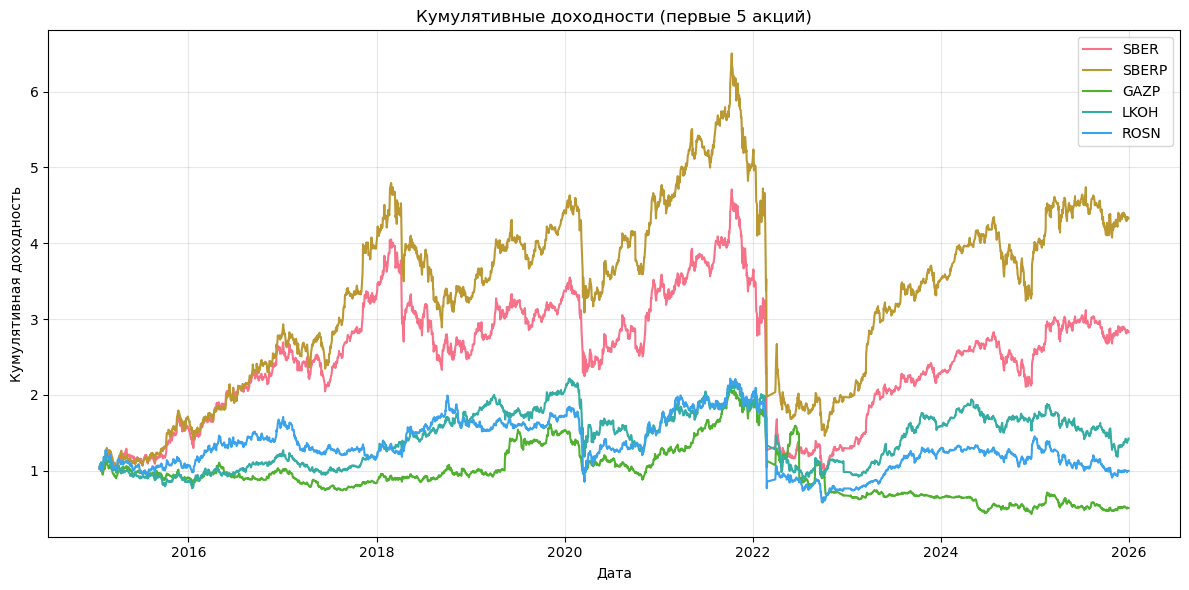

In [28]:
plt.figure(figsize=(12, 6))
for col in returns.columns[:5]:
    cumulative_returns = (1 + returns[col]).cumprod()
    plt.plot(returns.index, cumulative_returns, label=col)

plt.title('Кумулятивные доходности (первые 5 акций)')
plt.xlabel('Дата')
plt.ylabel('Кумулятивная доходность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2.a Скользящее окно

In [29]:
rolling_results = rolling_window_analysis(returns, window_size='1Y', step_size='1Y')

In [30]:
print(f"\nПолучено окон: {len(rolling_results)}")

if rolling_results:
    first_date = list(rolling_results.keys())[0]
    first_result = rolling_results[first_date]
    
    print(f"\n--- Первое окно ---")
    print(f"Период: {first_result['window_start'].strftime('%Y-%m-%d')} - {first_date.strftime('%Y-%m-%d')}")
    print(f"Размер окна: {len(first_result['window_returns'])} наблюдений")
    print(f"Размер ковариационной матрицы: {first_result['covariance_matrix'].shape}")
    
    # Проверка ковариационной матрицы
    cov_matrix = first_result['covariance_matrix']
    print(f"\nСвойства ковариационной матрицы:")
    print(f"- Симметричность: {np.allclose(cov_matrix, cov_matrix.T)}")
    print(f"- Определитель: {np.linalg.det(cov_matrix):.6e}")


Получено окон: 10

--- Первое окно ---
Период: 2015-01-21 - 2016-01-21
Размер окна: 251 наблюдений
Размер ковариационной матрицы: (30, 30)

Свойства ковариационной матрицы:
- Симметричность: True
- Определитель: 2.870323e-106


Визуализация динамики средних доходностей во времени

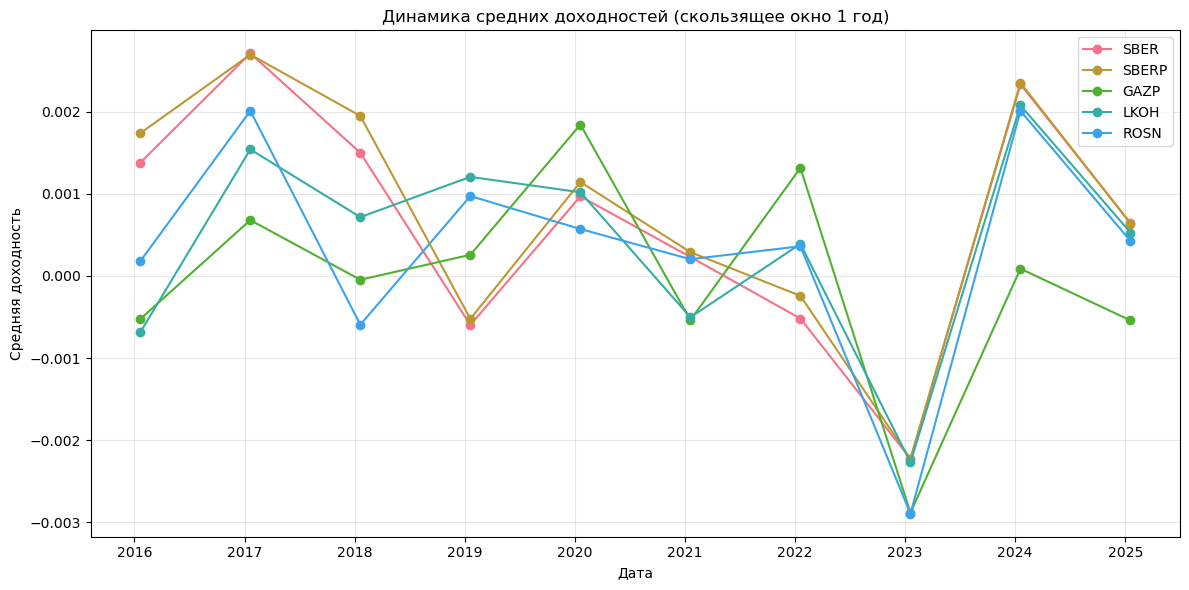

In [31]:
if rolling_results:
    dates = list(rolling_results.keys())
    mean_returns_history = [rolling_results[date]['mean_returns'] for date in dates]
    mean_returns_df = pd.DataFrame(mean_returns_history, index=dates, columns=returns.columns)
    
    plt.figure(figsize=(12, 6))
    for col in returns.columns[:5]:
        plt.plot(mean_returns_df.index, mean_returns_df[col], marker='o', label=col)
    
    plt.title('Динамика средних доходностей (скользящее окно 1 год)')
    plt.xlabel('Дата')
    plt.ylabel('Средняя доходность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Выводы**:
- Определитель матрицы очень мал (~2.87e-106), что характерно для 30x30 матрицы с сильной корреляцией активов
- Средние доходности не стабильны во времени - это демонстрирует, что историческая доходность — ненадежный прогноз будущего

#### 2.a Расширяющее окно

In [32]:
expanding_results = expanding_window_analysis(returns, step_size='1Y')

In [33]:
print(f"\nПолучено окон: {len(expanding_results)}")

if expanding_results:
    print("\n--- Динамика размера окна ---")
    for i, (date, result) in enumerate(list(expanding_results.items())[:5]):
        print(f"Окно {i+1}:  {date.strftime('%Y-%m-%d')} - {result['window_size']} наблюдений")
    print("...")
    
    last_date = list(expanding_results.keys())[-1]
    last_result = expanding_results[last_date]
    print(f"Окно {len(expanding_results)}: {last_date.strftime('%Y-%m-%d')} - {last_result['window_size']} наблюдений")


Получено окон: 10

--- Динамика размера окна ---
Окно 1:  2016-01-21 - 251 наблюдений
Окно 2:  2017-01-20 - 505 наблюдений
Окно 3:  2018-01-20 - 755 наблюдений
Окно 4:  2019-01-20 - 1008 наблюдений
Окно 5:  2020-01-20 - 1260 наблюдений
...
Окно 10: 2025-01-18 - 2475 наблюдений


Сравнение скользящего и расширяющегося окон

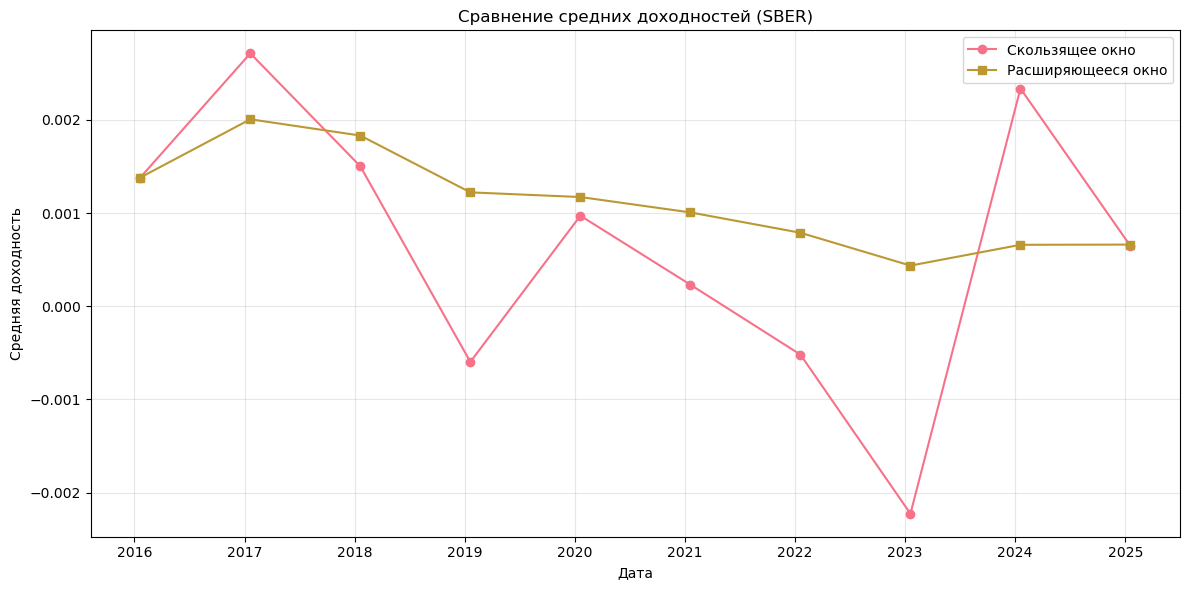

In [34]:
if rolling_results and expanding_results:
    rolling_dates = list(rolling_results.keys())
    expanding_dates = list(expanding_results.keys())
    
    ticker = returns.columns[0]
    
    rolling_means = [rolling_results[date]['mean_returns'][0] for date in rolling_dates]
    expanding_means = [expanding_results[date]['mean_returns'][0] for date in expanding_dates]
    
    plt.figure(figsize=(12, 6))
    plt.plot(rolling_dates, rolling_means, marker='o', label='Скользящее окно')
    plt.plot(expanding_dates, expanding_means, marker='s', label='Расширяющееся окно')
    plt.title(f'Сравнение средних доходностей ({ticker})')
    plt.xlabel('Дата')
    plt.ylabel('Средняя доходность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Выводы**:
- Скользящее окно реагирует быстрее на изменения рыночной ситуации (использует только свежие данные)
- Расширяющееся окно более стабильно (учитывает всю историю), но может отставать от текущих трендов
- Для краткосрочных прогнозов скользящее окно может быть предпочтительнее
- Для долгосрочных оценок — расширяющееся окно

### 3. Экспоненциальное забывание

- Скользящее окно (1 год)
- lambda=0.94

In [35]:
rolling_exp_results = rolling_window_analysis(
    returns, window_size='1Y', step_size='1Y', lambda_param=0.94
)

Сравнение обычного и экспоненциального взвешивания

Получено окон: 10


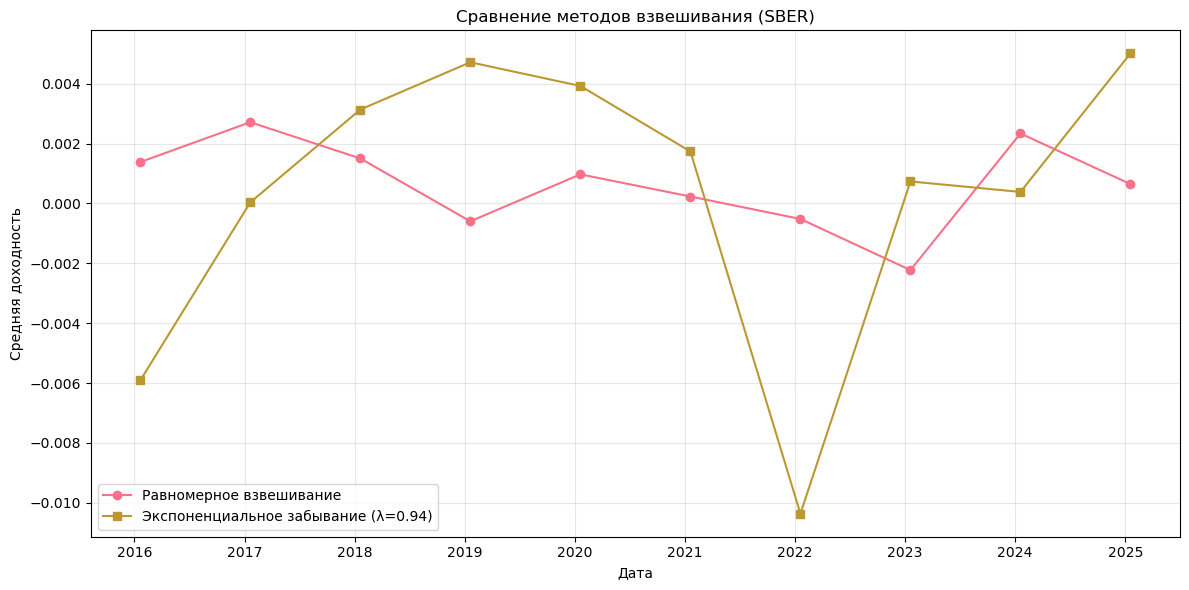


--- Численное сравнение для первой даты ---
Дата: 2016-01-21
Равномерное взвешивание: 0.001382
Экспоненциальное забывание: -0.005912
Разница: -0.007294


In [36]:
print(f"Получено окон: {len(rolling_exp_results)}")

if rolling_results and rolling_exp_results:
    ticker = returns.columns[0]
    ticker_idx = 0
    
    dates = list(rolling_results.keys())
    rolling_means = [rolling_results[date]['mean_returns'][ticker_idx] for date in dates]
    exp_means = [rolling_exp_results[date]['mean_returns'][ticker_idx] for date in dates]
    
    plt.figure(figsize=(12, 6))
    plt.plot(dates, rolling_means, marker='o', label='Равномерное взвешивание')
    plt.plot(dates, exp_means, marker='s', label='Экспоненциальное забывание (λ=0.94)')
    plt.title(f'Сравнение методов взвешивания ({ticker})')
    plt.xlabel('Дата')
    plt.ylabel('Средняя доходность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n--- Численное сравнение для первой даты ---")
    first_date = dates[0]
    print(f"Дата: {first_date.strftime('%Y-%m-%d')}")
    print(f"Равномерное взвешивание: {rolling_means[0]:.6f}")
    print(f"Экспоненциальное забывание: {exp_means[0]:.6f}")
    print(f"Разница: {exp_means[0] - rolling_means[0]:.6f}")

**Выводы:**
- Экспоненциальное забывание дает оценки, отличные от равномерного взвешивания
- Различия зависят от конкретной даты и динамики цен
- В периоды стабильности различия могут быть минимальными
- В периоды сильных изменений экспоненциальное забывание быстрее адаптируется

### Общие выводы по блоку
1) Нестабильность оценок: Доходности и риски акций значительно меняются во времени, поэтому статичные оценки могут быть ошибочными
2) Выбор метода взвешивания:
    - Для краткосрочных прогнозов: экспоненциальное забывание или скользящее окно
    - Для долгосрочных стратегий: расширяющееся окно
3) Важность регулярного пересчета: Портфельные веса нужно обновлять с использованием свежих данных
4) Диверсификация: Различия в динамике акций подтверждают важность диверсификации для снижения риска

### 4. Анализ влияния ограничений в optimizer на границу эффективных портфелей

В этом разделе выполняются пункты 4-8 задания.  
Мы берем один выбранный исторический подход из предыдущего блока и используем его как вход для optimizer.

**Выбор для пункта 4:**
- скользящее окно длиной 1 год,
- шаг 1 год,
- экспоненциальное забывание с `lambda = 0.94`,
- реально последнее доступное окно по последней дате выборки.



In [37]:
from task_4_8 import run_task_4_8

#### 4.1. Запуск расчета для пунктов 4-8

In [38]:
results_4_8 = run_task_4_8(
    returns=returns,
    asset_names=list(returns.columns),
    window_method='rolling',
    window_size='1Y',
    step_size='1Y',
    lambda_param=0.94,
    n_points=12,
    selection_mode='latest'
)

selected_window = results_4_8['selected_window']

print("Выбранное окно и схема взвешивания:")
print(f"Метод окна: {selected_window['window_method']}")
print(f"Размер окна: {selected_window['window_size']}")
print(f"Шаг окна: {selected_window['step_size']}")
print(f"Режим выбора окна: {selected_window['selection_mode']}")
print(f"Lambda: {selected_window['lambda_param']}")
print(f"Начало окна: {selected_window['window_start']}")
print(f"Конец окна: {selected_window['window_end']}")
print(f"Число наблюдений: {selected_window['window_n_obs']}")


Выбранное окно и схема взвешивания:
Метод окна: rolling
Размер окна: 1Y
Шаг окна: 1Y
Режим выбора окна: latest
Lambda: 0.94
Начало окна: 2025-01-03 00:00:00
Конец окна: 2025-12-30 00:00:00
Число наблюдений: 250


#### 4.2. Таблица сравнения сценариев

Основные характеристики четырех сценариев:
- число рассчитанных точек на границе,
- доходность и риск GMV-портфеля,
- диапазоны риск-доходность на границе,
- тип построения границы 


In [39]:
comparison_4_8 = results_4_8['comparison']
comparison_4_8

,scenario,frontier_mode,n_frontier_points,gmv_return,gmv_volatility,frontier_min_return,frontier_max_return,frontier_min_volatility,frontier_max_volatility
0,Пункт 5 - short allowed without limits,visual_fragment_of_unbounded_frontier,12,-0.095351,0.046825,-0.095351,3.079419,0.046825,0.163887
1,"Пункт 6 - short allowed, but each weight >= -25%",bounded_upper_branch,12,-0.130808,0.047540,-0.130808,9.311345,0.047540,1.718418
2,Пункт 7 - no short selling,bounded_upper_branch,12,-0.015747,0.107651,-0.015747,1.256831,0.107651,0.290119
3,Пункт 8 - each asset weight >= 2%,bounded_upper_branch,12,0.112191,0.140011,0.112191,0.612470,0.140011,0.206583


#### 4.3. График эффективных границ

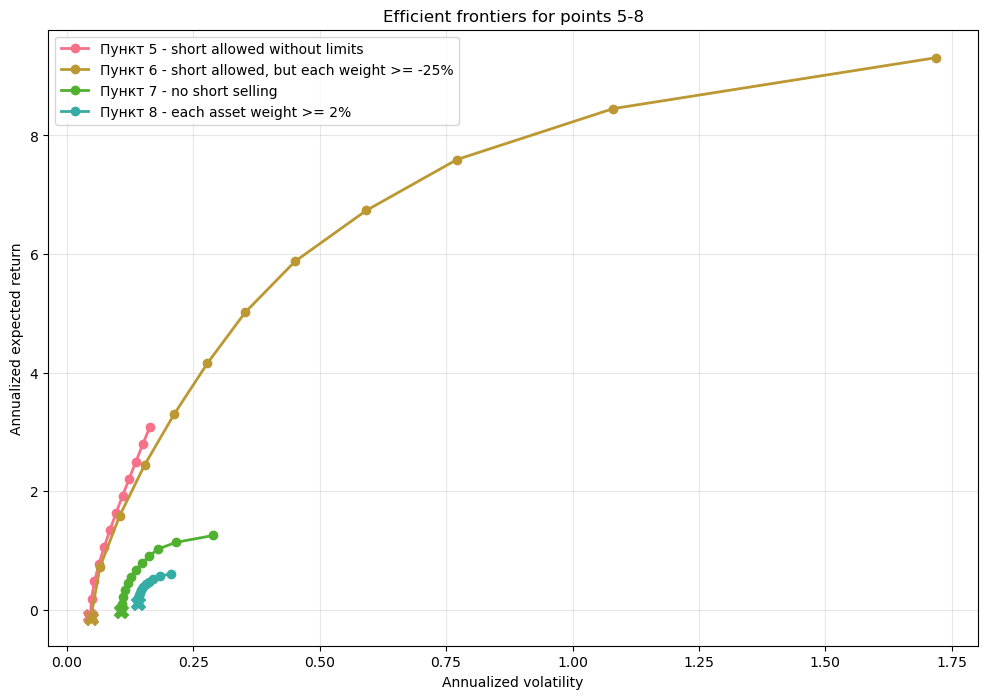

In [40]:
frontiers_4_8 = results_4_8['frontiers']
summaries_4_8 = results_4_8['summaries']

plt.figure(figsize=(12, 8))

for scenario_name, frontier_df in frontiers_4_8.items():
    plt.plot(
        frontier_df['portfolio_volatility'],
        frontier_df['portfolio_return'],
        marker='o',
        linewidth=2,
        label=scenario_name
    )

    gmv = summaries_4_8[scenario_name]
    plt.scatter(
        gmv['volatility'],
        gmv['return'],
        s=100,
        marker='X'
    )

plt.xlabel('Annualized volatility')
plt.ylabel('Annualized expected return')
plt.title('Efficient frontiers for points 5-8')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 4.4. Структура GMV-портфелей

In [41]:
for scenario_name, summary in summaries_4_8.items():
    print('=' * 80)
    print(f'Сценарий: {scenario_name}')
    print(f"GMV return: {summary['return']:.4f}")
    print(f"GMV volatility: {summary['volatility']:.4f}")
    print('Top-10 weights in GMV portfolio:')
    print(summary['weights'].head(10))
    print()

Сценарий: Пункт 5 - short allowed without limits
GMV return: -0.0954
GMV volatility: 0.0468
Top-10 weights in GMV portfolio:
SBERP    1.232359
AKRN     0.407890
CHMF     0.149221
SIBN     0.144895
TATNP    0.139940
MTSS     0.119795
ROSN     0.082959
PHOR     0.079056
BSPB     0.073451
IRAO     0.064005
dtype: float64

Сценарий: Пункт 6 - short allowed, but each weight >= -25%
GMV return: -0.1308
GMV volatility: 0.0475
Top-10 weights in GMV portfolio:
SBERP    0.892130
AKRN     0.388161
SIBN     0.159493
MTSS     0.154654
CHMF     0.118143
MAGN     0.091610
PHOR     0.079595
LSRG     0.073780
IRAO     0.072621
TATNP    0.062783
dtype: float64

Сценарий: Пункт 7 - no short selling
GMV return: -0.0157
GMV volatility: 0.1077
Top-10 weights in GMV portfolio:
AKRN     2.965112e-01
SBERP    2.931709e-01
BSPB     1.137750e-01
SNGSP    8.812304e-02
PHOR     7.802008e-02
LSRG     7.722352e-02
MTSS     3.990072e-02
FEES     1.327562e-02
LKOH     5.317666e-17
TATNP    3.447103e-17
dtype: float64


В пункте 5 риск минимальный, но такой вариант слишком теоретический.

В пункте 6 результат почти такой же, но уже намного ближе к практике.

В пункте 7 после запрета коротких продаж риск заметно растет.

В пункте 8 из-за самых жестких ограничений риск становится максимальным.

### Общие выводы по блоку 4-8

1. Ограничения в optimizer заметно меняют эффективную границу и структуру оптимальных портфелей.  
2. Чем жестче ограничения на веса, тем уже множество достижимых портфелей.  
3. Наиболее свободный сценарий обычно дает минимальный риск за счет хеджирования.  
4. Наиболее жесткий сценарий с минимумом 2% в каждую бумагу часто приводит к вынужденной диверсификации и росту риска.
